preprocessing: cümleleri token'lara çevirme

word2vec ve fasttext modelleri eğitilir

her iki modelden elde edilen vektörleri pca(principle component analysis) analizi ile 3 boyuta indirgenir

kelime veötrlerini 3 boyutlu olarak görselleştir

In [3]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.1 MB/s eta 0:00:00


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess

In [7]:
#örnek veri seti
cumleler=[
    "Köpek çok tatlı bir hayvandır.",
    "Köpekler evcil hayvanlardır."
    "Kediler genellikle bağımsız hareket etmeyi severler.",
    "Köpekler sadık ve dost canlısı hayvanlardır",
    "Hayvanlar insanlar için iyi bir arkadaşlardır.",
    "Türkiye'nin başkenti Ankara 'dır.",
    "Türkiye'de ve AnkaradaGaziantep yemekleri çok güzel."
]

#cümleleri tokenize et (küçük harf ve noktalama temizliği otomatik yapılır)
tokenize_cumleler=[simple_preprocess(c) for c in cumleler]
print(tokenize_cumleler)

[['köpek', 'çok', 'tatlı', 'bir', 'hayvandır'], ['köpekler', 'evcil', 'hayvanlardır', 'kediler', 'genellikle', 'bağımsız', 'hareket', 'etmeyi', 'severler'], ['köpekler', 'sadık', 've', 'dost', 'canlısı', 'hayvanlardır'], ['hayvanlar', 'insanlar', 'için', 'iyi', 'bir', 'arkadaşlardır'], ['türkiye', 'nin', 'başkenti', 'ankara', 'dır'], ['türkiye', 'de', 've', 'yemekleri', 'çok', 'güzel']]


In [8]:
#word2vec
word2vec_model=Word2Vec(
    sentences=tokenize_cumleler, #eğitim verisi
    vector_size=50, #vektör boyutu
    window=5, #pencere boyutu
    min_count=1, #en az kaç defa geçen kelimeleri alsın
    sg=0, #skip gram=1
)

In [9]:
#fast text
fasttext_model=FastText(
    sentences=tokenize_cumleler, #eğitim verisi
    vector_size=50, #vektör boyutu
    window=5, #pencere boyutu
    min_count=1, #en az kaç defa geçen kelimeleri alsın
    sg=0, #skip gram=1
)

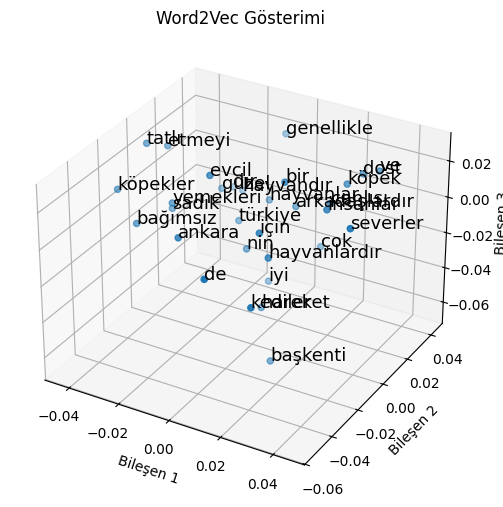

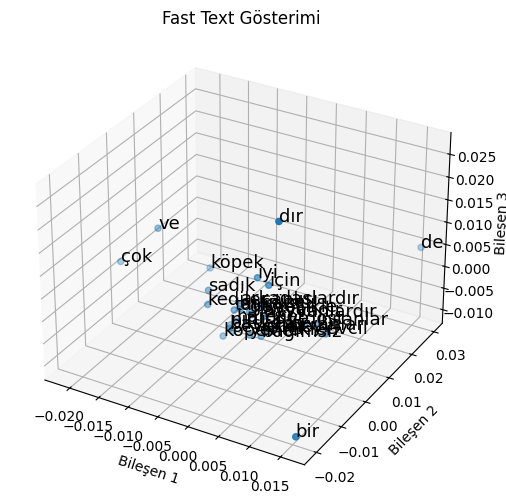

In [22]:
def plot_word_embeddings(model, baslik):
  #modelin kelime vektörlerini al
  kelime_vektor=model.wv

  #ilk 1000 kelimeyi al
  kelimeler=list(kelime_vektor.index_to_key)[:1000]
  vektorler=[kelime_vektor[w] for w in kelimeler]

  #PCA boyut indirgemesi
  pca=PCA(n_components=3) #3 boyuta indirgeme
  indirgenmis_vektorler= pca.fit_transform(vektorler)

  #3d görselleştirme
  fig=plt.figure(figsize=(8,6))
  ax=fig.add_subplot(111, projection="3d")

  #noktaları çizdir
  ax.scatter(indirgenmis_vektorler[:,0], indirgenmis_vektorler[:,1], indirgenmis_vektorler[:,2])

  #kelimeleri bu noktaların yanına yaz
  for i, kelime in enumerate(kelimeler):
    ax.text(indirgenmis_vektorler[i,0], indirgenmis_vektorler[i,1], indirgenmis_vektorler[i,2], kelime, fontsize = 13)

  ax.set_title(baslik)
  ax.set_xlabel("Bileşen 1")
  ax.set_ylabel("Bileşen 2")
  ax.set_zlabel("Bileşen 3")
  plt.show()

plot_word_embeddings(word2vec_model, "Word2Vec Gösterimi")
plot_word_embeddings(fasttext_model, "Fast Text Gösterimi")